# Advanced Methods
1. MLP
2. LSTM
3. Prophet

## MLPs for Univariate Time Series Forecasting

We have been dealing with univariate time series for the entire course so far. Examples include:
- Daily temperatures
- Stock prices every minute
- Monthly sales of a product

A **univariate** time series means we’re dealing with only **one variable** (e.g., temperature), and the goal is to **predict future values** based on its past behavior.


### Neural Networks

A simple neural network

![Simple Neural Network](img/nnet1-1.png)

- Coefficients attached to predictors are called weights
- Forecasts are obtained by a linear combination of inputs

A Neural network with four inputs and one hidden layer with three hidden neurons.


![Neural Network](img/nnet2-1.png)


* A **multilayer feed-forward network** where each layer of nodes receives inputs from the previous layers.
* Inputs to each node combined using linear combination.
* Result modified by nonlinear function before being output.

Inputs to hidden neuron $j$ linearly combined:
$$
z_j = b_j + \sum_{i=1}^4 w_{i,j} x_i.
$$
Modified using nonlinear function such as a sigmoid:
$$
s(z) = \frac{1}{1+e^{-z}},
$$
This tends to reduce the effect of extreme input values, thus making the network somewhat robust to outliers.

* Weights take random  values to begin with, which are then updated using the observed data.
* There is an element of randomness in the predictions. So the network is usually trained several times using different random starting points, and the results are averaged.
* Number of hidden layers, and the number of nodes in each hidden layer, must be specified in advance.

## Neural Network autoregression

* Lagged values of the time series can be used as inputs to a neural network.
* NNAR($p,k$): $p$ lagged inputs and $k$ nodes in the single hidden layer.
* NNAR($p,0$) model is equivalent to an ARIMA($p,0,0$) model but without stationarity restrictions.
* Seasonal NNAR($p,P,k$): inputs $(y_{t-1},y_{t-2},\dots,y_{t-p},y_{t-m},y_{t-2m},y_{t-Pm})$ and $k$ neurons in the hidden layer.
* NNAR($p,P,0$)$_m$ model is equivalent to an ARIMA($p,0,0$)($P$,0,0)$_m$ model but without stationarity restrictions.


###  What is an MLP (Multi-Layer Perceptron)?

A **Multi-Layer Perceptron (MLP)** is a type of **neural network** made up of layers of interconnected "neurons." Each neuron performs a mathematical operation, helping the network learn patterns in the data.

MLPs are often used for:

- Classification (e.g., email spam detection)
- Regression (e.g., predicting prices)
- Time series forecasting (when data is formatted appropriately)


## How Can MLPs Be Used for Time Series Forecasting?

MLPs don’t understand time on their own. To use them for time series, we must **reformat the time series into a supervised learning problem**.

### Example: Sliding Window

Imagine a time series of daily sales:
```
[100, 110, 125, 130, 140, 150]
```

We can use past values to predict the next one:

- Input (X): [100, 110, 125] → Output (y): 130
- Input (X): [110, 125, 130] → Output (y): 140
- Input (X): [125, 130, 140] → Output (y): 150

This is called a **sliding window** or **lagged features** approach.




In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/Alcohol_Sales.csv", infer_datetime_format=True, index_col='DATE')

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_36006/2411402033.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv("data/Alcohol_Sales.csv", infer_datetime_format=True, index_col='DATE')


In [3]:
df.head()

,Sales
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [4]:
df.tail()

,Sales
DATE,
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174
2018-12-01,15504
2019-01-01,10718


In [5]:
df.isna().sum()

Sales    0
dtype: int64

In [6]:
df.shape

(325, 1)


Hyperparameters:

* `n_input`: The number of lag observations to use as input to the model.
* `n_nodes`: The number of nodes to use in the hidden layer.
* `n_epochs`: The number of times to expose the model to the whole training dataset.
* `n_batch`: The number of samples within an epoch after which the weights are updated.



In [7]:
#hyperparameters
n_input = 12
n_nodes = 100
n_epochs = 100

In [8]:
# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
  return data[:-n_test], data[-n_test:]

In [9]:
# transform list into supervised learning format
def series_to_supervised(data, n_in, n_out=1):
  df = pd.DataFrame(data)
  cols = list()
  # input sequence (t-n, ... t-1)
  for i in range(n_in, 0, -1):
    cols.append(df.shift(i))
  # forecast sequence (t, t+1, ... t+n)
  for i in range(0, n_out):
    cols.append(df.shift(-i))
  # put it all together
  agg = pd.concat(cols, axis=1)
  # drop rows with NaN values
  agg.dropna(inplace=True)

  return agg.values

series_to_supervised(df.values, 12)

array([[ 3459.,  3458.,  4002., ...,  4240.,  4936.,  3031.],
       [ 3458.,  4002.,  4564., ...,  4936.,  3031.,  3261.],
       [ 4002.,  4564.,  4221., ...,  3031.,  3261.,  4160.],
       ...,
       [13261., 14265.,  9564., ..., 12396., 13914., 14174.],
       [14265.,  9564., 10415., ..., 13914., 14174., 15504.],
       [ 9564., 10415., 12683., ..., 14174., 15504., 10718.]])

In [11]:
train, test = train_test_split(df, 21)

print(f"train shape : {train.shape}, test shape : {test.shape}")

train shape : (304, 1), test shape : (21, 1)


In [12]:
data = series_to_supervised(train, n_input)
train_x, train_y = data[:, :-1], data[:, -1]
train_x.shape, train_y.shape

((292, 12), (292,))

In [13]:
# define model

class TimeSeriesMLPModel(nn.Module):

    def __init__(self, n_input, n_nodes) -> None:
        super().__init__()
        self.lm_linear = nn.Sequential(
            nn.Linear(in_features=n_input, out_features=n_nodes),
            nn.ReLU(),
            nn.Linear(in_features=n_nodes, out_features=1),
            )
    def forward(self, X):

        B, T = X.shape
        logits = self.lm_linear(X)
        return logits


In [14]:
n_input = 12
n_nodes = 100
mlp_model  = TimeSeriesMLPModel(n_input, n_nodes)

In [15]:
mlp_model

TimeSeriesMLPModel(
  (lm_linear): Sequential(
    (0): Linear(in_features=12, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [24]:
#loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters())

In [25]:
#convert datatype
train_x, train_y = torch.tensor(train_x, dtype=torch.float32), torch.tensor(train_y, dtype=torch.float32)

In [30]:
test.iloc[0, 0]

13545

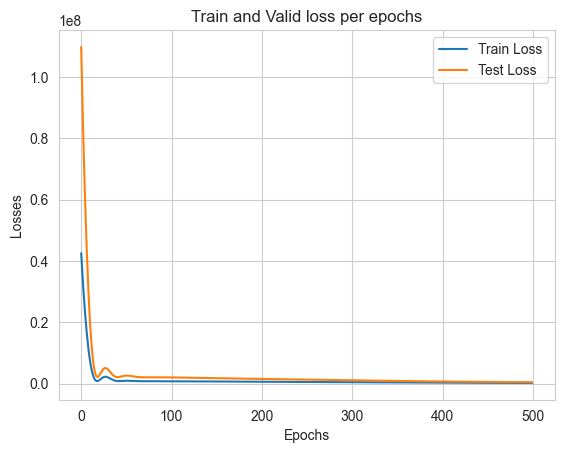

In [31]:
#training loop
n_epochs = 500
train_losses = []
test_losses = []

for _ in range(n_epochs):

    optimizer.zero_grad()
    logits = mlp_model.forward(train_x)
    loss = criterion(logits.view(-1), train_y)
    train_losses.append(loss.item())
    #validation
    #history
    with torch.no_grad():
        history = train_x[-1].tolist() + train_y[-1][None].tolist()

        y_pred_values = []
        y_true = []
        for i in range(len(test)):

            test_points = torch.tensor(history[-n_input:], dtype=torch.float32).view(1, n_input)
            yhat =  mlp_model.forward(test_points)
            history.append(test.iloc[i, 0])
            y_pred_values.append(yhat.item())
            y_true.append(test.iloc[i, 0])

        y_pred_values = torch.tensor(y_pred_values, dtype=torch.float32)
        y_true = torch.tensor(y_true, dtype=torch.float32)
        test_loss = criterion(y_pred_values, y_true)
        test_losses.append(test_loss.item())
    loss.backward()
    optimizer.step()


plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

# Adding labels and legend
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.title('Train and Valid loss per epochs')
plt.legend()

# Show the plot
plt.show()

In [32]:
train_x[0], train_y[0]

(tensor([3459., 3458., 4002., 4564., 4221., 4529., 4466., 4137., 4126., 4259.,
         4240., 4936.]),
 tensor(3031.))

In [33]:
train_x[1], train_y[1]

(tensor([3458., 4002., 4564., 4221., 4529., 4466., 4137., 4126., 4259., 4240.,
         4936., 3031.]),
 tensor(3261.))

In [34]:
test = test.values

In [36]:
train_y[-1]

tensor(11491.)

In [37]:
train_y[-1][None].tolist()

[11491.0]

In [38]:
#history
history = train_x[-1].tolist() + train_y[-1][None].tolist()
len(history)
torch.tensor(history[-n_input:], dtype=torch.float32).shape


torch.Size([12])

In [39]:
test[0]

array([13545])

In [40]:
#history
history = train_x[-1].tolist() + train_y[-1][None].tolist()

y_pred_values = []
y_true = []
for i in range(len(test)):

    test_points = torch.tensor(history[-n_input:], dtype=torch.float32).view(1, n_input)
    yhat =  mlp_model.forward(test_points)
    history.append(test[i][0])
    y_pred_values.append(yhat.item())
    y_true.append(test[i][0])

y_pred_values = torch.tensor(y_pred_values, dtype=torch.float32)
y_true = torch.tensor(y_true, dtype=torch.float32)
test_loss = criterion(y_pred_values, y_true)

print(f"Test loss : {test_loss}")

Test loss : 440946.65625


In [46]:
df.index

Index(['1992-01-01', '1992-02-01', '1992-03-01', '1992-04-01', '1992-05-01',
       '1992-06-01', '1992-07-01', '1992-08-01', '1992-09-01', '1992-10-01',
       ...
       '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01',
       '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01'],
      dtype='object', name='DATE', length=325)

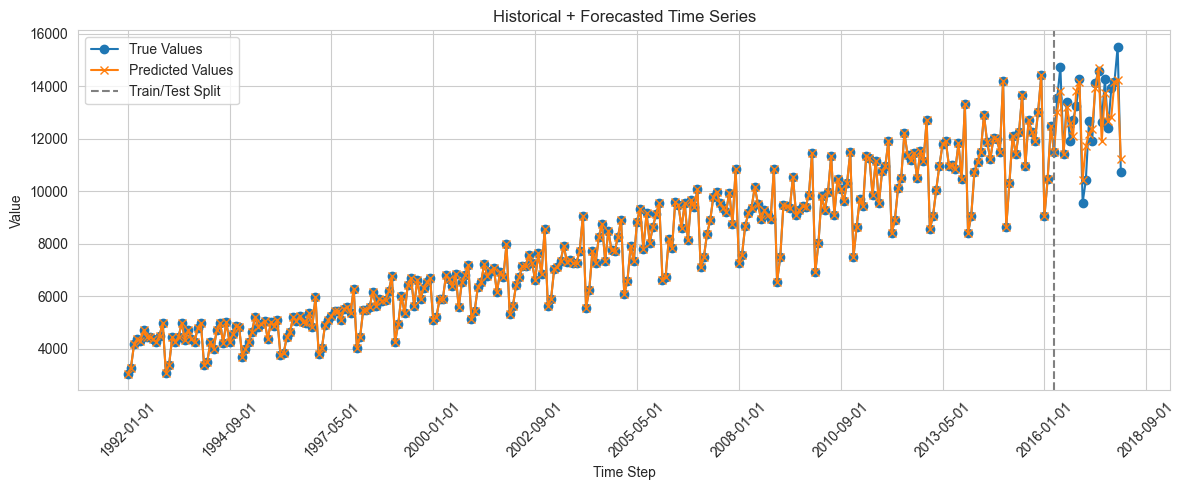

In [48]:
full_series = torch.cat([train_y, y_true])  # or use `.numpy()` if needed
full_pred = torch.cat([train_y, y_pred_values])  # match shape

plt.figure(figsize=(12, 5))
plt.plot(full_series, label='True Values', marker='o')
plt.plot(full_pred, label='Predicted Values', marker='x')
plt.axvline(x=len(train_y)-1, color='gray', linestyle='--', label='Train/Test Split')

step = max(1, len(df.index) // 10)
plt.xticks(ticks=range(0, len(df.index), step), labels=df.index[::step], rotation=45)
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Historical + Forecasted Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


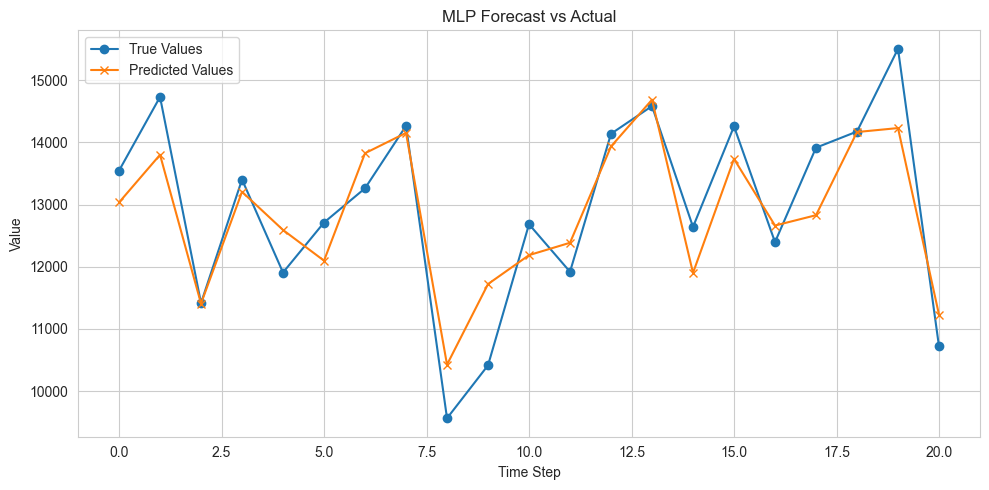

In [41]:
# Plot the predicted vs actual values
plt.figure(figsize=(10, 5))
plt.plot(y_true, label='True Values', marker='o')
plt.plot(y_pred_values, label='Predicted Values', marker='x')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('MLP Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Why Use MLPs for Time Series Forecasting?

### Advantages:

1. **Can model complex patterns**
   MLPs can learn nonlinear relationships, which classical models like ARIMA might miss.

2. **Fast and simple to implement**
   Especially useful when you don’t need to model very long sequences.

3. **Flexible**
   You can easily adjust the number of inputs (lags), hidden layers, and neurons to fit different types of data.



## Limitations of MLPs for Time Series

1. **No sense of time**
   MLPs don’t "know" the order of data unless we explicitly give it lagged values.

2. **Not good with long dependencies**
   For example, if what happened 100 days ago still affects today, MLPs might not capture that easily.

3. **Need manual feature creation**
   You have to decide how many previous values to use (e.g., 3 days back? 10 days back?).



## Is MLP Better Than Classical Models?

| Feature              | Classical Models (e.g. ARIMA) | MLP |
|---------------------|-------------------------------|-----|
| Handles nonlinearity| ❌ Often not well              | ✅ Yes |
| Requires stationary data | ✅ Yes                    | ❌ Not necessarily |
| Easy to interpret   | ✅ Yes                        | ❌ No (black box) |
| Needs manual lag setup | ✅ Yes                    | ✅ Yes |
| Works well for long-term memory | ❌ Not really     | ❌ Also not ideal |

### Conclusion:

- Use **MLPs** when you expect **nonlinear patterns** and have **enough data**.
- Use **classical models** like ARIMA when the data is **well-behaved**, **linear**, and **easy to interpret**.
- For **complex sequences** with long-term dependencies, consider models like **LSTM** or **Transformer-based models**.


## LSTM (Long Short-Term Memory)

**LSTM (Long Short-Term Memory)** is a special type of **Recurrent Neural Network (RNN)** that is designed to handle **sequential data** like time series. Unlike simple RNNs, LSTMs are built to **remember patterns over long periods of time** and to **handle vanishing gradients**, making them powerful for time series tasks.

### Why Use LSTM for Time Series Forecasting?

Traditional models like **ARIMA** or **Exponential Smoothing** assume linear relationships and often rely on stationary data. While they're effective for many use cases, they may struggle with:

- **Nonlinear relationships**
- **Long-term dependencies**
- **Multiple influencing factors**

**LSTMs** are a strong alternative when:

- The time series is **nonlinear**
- There are **complex patterns** or long dependencies
- You want a **more flexible model** that can learn directly from the data

## Key Differences from MLP

| Feature            | MLP                     | LSTM                      |
|--------------------|-------------------------|---------------------------|
| Sequence-aware     | ❌ No (flat input)       | ✅ Yes (step-by-step input)|
| Handles long-term dependencies | ❌ Poorly          | ✅ Very well               |
| Input shape        | Fixed-size vector       | Sequence of vectors       |
| Memory of the past | ❌ None                  | ✅ Learns what to remember |

---

### When Should You Use LSTM?

#### Use LSTM if:
- Your data has **temporal patterns** across long time spans
- You expect **nonlinear** dynamics
- You want a model that **learns from sequences** without hand-crafting features

#### Avoid LSTM if:
- Your time series is **very short**
- You're doing **real-time inference** with strict latency constraints
- A **simpler model performs well** (e.g., MLP or ARIMA)



### Example Workflow for LSTM Forecasting

1. **Prepare Data**
   - Normalize your time series
   - Create input/output pairs using sliding windows

2. **Define LSTM Model**
   - Input: sequences of shape `[batch_size, sequence_length, 1]`
   - Output: one or more future values

3. **Train the Model**
   - Use MSE or MAE loss
   - Use Adam or RMSprop optimizer

4. **Make Forecasts**
   - Predict one step ahead recursively
   - Or use sequence-to-sequence approach for multi-step forecasting

In [49]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# This relates to plotting datetime values with matplotlib:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [51]:
df = pd.read_csv('data/Alcohol_Sales.csv',index_col=0,parse_dates=True)
len(df)

325

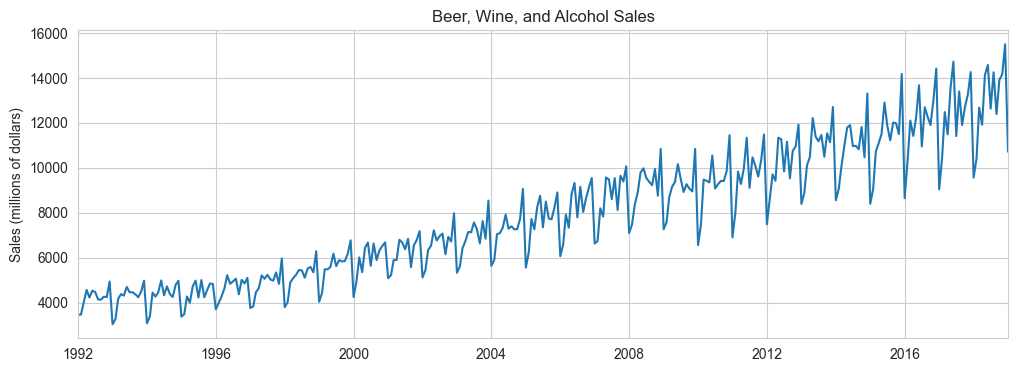

In [53]:
plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['Sales'])
plt.show()

In [54]:
# Extract values from the source .csv file
y = df['Sales'].values.astype(float)

# Define a test size
test_size = 12

# Create train and test sets
train_set = y[:-test_size]
test_set = y[-test_size:]

In [55]:
print(f"shape of train_set : {train_set.shape}")
print(f"shape of test_set : {test_set.shape}")

shape of train_set : (313,)
shape of test_set : (12,)


It's worth noting that in our previous exercise the train and test sets were tensors. Here they're numpy arrays. This is because one of the steps we're about to perform outputs an array, and we'd have to turn it into a tensor anyway.

### Normalize the data

 The formula for normalizing data around zero is:<br>

$$X_{norm} = \frac{X - \mu} {\sigma}$$
 where $mu$ is the population mean, and $sigma$ is the population standard deviation.<br>

Ultimately we want to perform <a href='https://en.wikipedia.org/wiki/Feature_scaling'>min/max feature scaling</a> so that our values fall between -1 and 1, as this makes hyperparameters converge faster.<br>The formula for this would be:<br>
$$X^{\prime} = a + \frac{(X - X_{min}) (b - a)} {X_{max} - X_{min}}$$
where $a={-1}$ and $b=1$<br>

We can use scikit-learn to do this, with <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html'><tt><strong>sklearn.preprocessing.MinMaxScaler()</strong></tt></a>

NOTE: We only want to normalize the training set to avoid data leakage. If we include the test set then the higher average values of the test set could become part of the signal in the training set. There's a good article on data leakage <a href='test_set = input_data(test_norm,window_size)'>here</a>.

After using transformed data to train the model and generate predictions, we'll inverse_transform the predicted values so that we can compare them to the actual test data.

In [56]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))

In [57]:
# Normalize the training set
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [58]:
train_norm[:10]

array([[-0.92683135],
       [-0.92700231],
       [-0.83400291],
       [-0.73792632],
       [-0.79656381],
       [-0.74390974],
       [-0.75467989],
       [-0.81092401],
       [-0.81280451],
       [-0.79006753]])

#### Data preparation for LSTM training

Here we'll create our list of (seq/label) tuples from the training set. Recall that an LSTM consumes a window of samples toward the first prediction, so the size of our training set will become ((325 - test_size) - window_size).

In [59]:
# Convert train_norm from an array to a tensor
train_norm = torch.FloatTensor(train_norm).view(-1)

# Define a window size
window_size = 12

# Define function to create seq/label tuples
def input_data(seq, ws):  # ws is the window size
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

# Apply the input_data function to train_norm
train_data = input_data(train_norm,window_size)
len(train_data)  # this should equal 325-12-12


301

In [60]:
train_data[:2]

[(tensor([-0.9268, -0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109,
          -0.8128, -0.7901, -0.7933, -0.6743]),
  tensor([-1.])),
 (tensor([-0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109, -0.8128,
          -0.7901, -0.7933, -0.6743, -1.0000]),
  tensor([-0.9607]))]

#### Define the model
We will be using an LSTM layer of size (1, 100)

In [61]:
class SalesPredictor(nn.Module):

    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
        self.hidden = (torch.zeros(1, 1, self.hidden_size),
                       torch.zeros(1, 1, self.hidden_size))
    def forward(self, seq):
        out, self.hidden = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(out.view(len(seq), -1))
        return pred[-1]

#### Instantiate the model and define the loss and optimizer

In [62]:
predictorModel = SalesPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(predictorModel.parameters(), lr=0.001)

predictorModel

SalesPredictor(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

#### Model's training

In [63]:
epochs = 100

import time
start_time = time.time()

for epoch in range(epochs):

    # extract the sequence & label from the training data
    for seq, y_train in train_data:

        # reset the parameters and hidden states
        optimizer.zero_grad()
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                        torch.zeros(1,1,predictorModel.hidden_size))

        y_pred = predictorModel(seq)

        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')

print(f'\nDuration: {time.time() - start_time:.0f} seconds')


Epoch:  1 Loss: 0.35820946
Epoch:  2 Loss: 0.25512421
Epoch:  3 Loss: 0.41387516
Epoch:  4 Loss: 0.35911766
Epoch:  5 Loss: 0.33359525
Epoch:  6 Loss: 0.32936537
Epoch:  7 Loss: 0.33420116
Epoch:  8 Loss: 0.27635646
Epoch:  9 Loss: 0.29551452
Epoch: 10 Loss: 0.27378762
Epoch: 11 Loss: 0.28063399
Epoch: 12 Loss: 0.27041367
Epoch: 13 Loss: 0.23998778
Epoch: 14 Loss: 0.23316212
Epoch: 15 Loss: 0.15811697
Epoch: 16 Loss: 0.08846880
Epoch: 17 Loss: 0.04117573
Epoch: 18 Loss: 0.00179942
Epoch: 19 Loss: 0.04223474
Epoch: 20 Loss: 0.17753665
Epoch: 21 Loss: 0.02136381
Epoch: 22 Loss: 0.01657988
Epoch: 23 Loss: 0.03467460
Epoch: 24 Loss: 0.03049375
Epoch: 25 Loss: 0.01501188
Epoch: 26 Loss: 0.00840535
Epoch: 27 Loss: 0.01045943
Epoch: 28 Loss: 0.00820927
Epoch: 29 Loss: 0.01745467
Epoch: 30 Loss: 0.01726970
Epoch: 31 Loss: 0.01688443
Epoch: 32 Loss: 0.01373604
Epoch: 33 Loss: 0.00844972
Epoch: 34 Loss: 0.00837966
Epoch: 35 Loss: 0.01051538
Epoch: 36 Loss: 0.00579819
Epoch: 37 Loss: 0.00776700
E

#### Forecast

In [64]:
future = 12

# Add the last window of training values to the list of predictions
preds = train_norm[-window_size:].tolist()

# Set the model to evaluation mode
predictorModel.eval()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                        torch.zeros(1,1,predictorModel.hidden_size))
        preds.append(predictorModel(seq).item())

In [65]:
preds[window_size:]

[0.2766830623149872,
 0.5317299962043762,
 0.488637238740921,
 0.8321061134338379,
 0.9701417684555054,
 0.5311902165412903,
 0.7659194469451904,
 0.5166600346565247,
 0.6154504418373108,
 0.7332748770713806,
 0.9368739128112793,
 0.08043772727251053]

Let's invert the prediction so that we can compare them with original values in test sets.

Note that inverse_transform uses the most recently applied parameters; we can rescale based on the test data, but not on the previous training data.


In [66]:
true_prediction = scaler.inverse_transform(np.array(preds[window_size:]).reshape(1, -1))
true_prediction = true_prediction.squeeze()

In [67]:
df['Sales'][-12:]

DATE
2018-02-01    10415
2018-03-01    12683
2018-04-01    11919
2018-05-01    14138
2018-06-01    14583
2018-07-01    12640
2018-08-01    14257
2018-09-01    12396
2018-10-01    13914
2018-11-01    14174
2018-12-01    15504
2019-01-01    10718
Name: Sales, dtype: int64

#### Plot the results

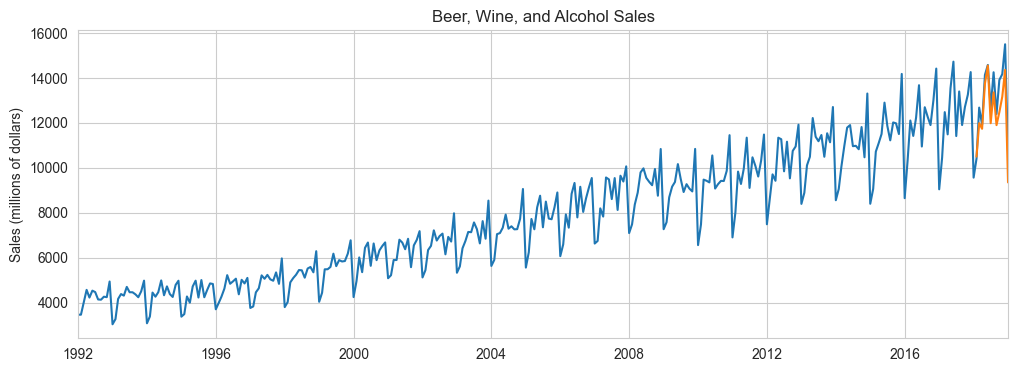

In [68]:
x = np.arange('2018-02-01', '2019-02-01', dtype='datetime64[M]').astype('datetime64[D]')

plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['Sales'])
plt.plot(x,true_prediction)
plt.show()

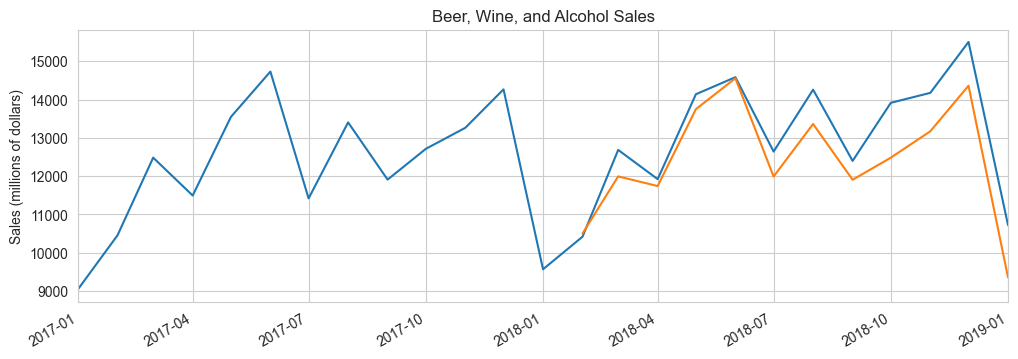

In [71]:
fig = plt.figure(figsize=(12,4))
plt.title('Beer, Wine, and Alcohol Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
fig.autofmt_xdate()

# Select the end of the graph with slice notation:
plt.plot(df['Sales']['2017-01-01':])
plt.plot(x,true_prediction)
plt.show()

## Prophet

## What is Prophet?

**Prophet** is an **open-source forecasting tool developed by Facebook** designed to handle time series data that has:

- **Strong seasonality**
- **Holidays or special events**
- **Trends and changepoints**

It’s built to be:

- **Accurate**
- **Robust to missing data and outliers**
- **Easy to use**, even for non-experts


## What Kind of Time Series is Prophet Good For?

### Works well when your data has:

- Daily, weekly, yearly **seasonal patterns**
- **Holiday effects** (e.g., Christmas, weekends)
- **Nonlinear trends** with abrupt changes

### Not ideal for:
- High-frequency data (seconds, milliseconds)
- Complex nonlinear patterns with no seasonality
- Short time series with little historical data


## How Prophet Works

Prophet is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

$$ y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

where
- $g(t)$ describes a piecewise-linear trend (linear or logistic growth)
- $s(t)$ describes the various seasonal patterns (daily, weekly, yearly - Fourier terms)
- $h(t)$ captures holidays effects (custom events that affect values)
- and $\epsilon_t$ is a white noise error term (unexplained variation)

## Input Format

Prophet requires a DataFrame with two columns:

| ds (date)     | y (value) |
|---------------|-----------|
| 2021-01-01    | 123.0     |
| 2021-01-02    | 127.5     |

## Typical workflow with Prophet

1. Prepare data
2. Fit the model
3. Forecast
4. Analysis

In [17]:
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import performance_metrics, cross_validation

### Data

In [22]:
df = pd.read_csv("data/RestaurantVisitors.csv", infer_datetime_format=True, index_col='date', parse_dates=True)

df.head()

/var/folders/72/x6_kg98117nd5xkqbx_bl3dc0000gn/T/ipykernel_36006/638171679.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv("data/RestaurantVisitors.csv", infer_datetime_format=True, index_col='date', parse_dates=True)


,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2016-01-01,Friday,1,New Year's Day,65.0,25.0,67.0,139.0,296.0
2016-01-02,Saturday,0,na,24.0,39.0,43.0,85.0,191.0
2016-01-03,Sunday,0,na,24.0,31.0,66.0,81.0,202.0
2016-01-04,Monday,0,na,23.0,18.0,32.0,32.0,105.0
2016-01-05,Tuesday,0,na,2.0,15.0,38.0,43.0,98.0


In [25]:
df.tail()

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-05-27,Saturday,0,na,NaN,NaN,NaN,NaN,NaN
2017-05-28,Sunday,0,na,NaN,NaN,NaN,NaN,NaN
2017-05-29,Monday,1,Memorial Day,NaN,NaN,NaN,NaN,NaN
2017-05-30,Tuesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-05-31,Wednesday,0,na,NaN,NaN,NaN,NaN,NaN


In [26]:
df.isna().sum()

weekday          0
holiday          0
holiday_name     0
rest1           39
rest2           39
rest3           39
rest4           39
total           39
dtype: int64

In [30]:
df[df.index>='2017-01-01'].head(50)

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-01-01,Sunday,1,New Year's Day,48.0,43.0,47.0,118.0,256.0
2017-01-02,Monday,0,na,7.0,5.0,43.0,75.0,130.0
2017-01-03,Tuesday,0,na,39.0,34.0,16.0,55.0,144.0
2017-01-04,Wednesday,0,na,23.0,24.0,23.0,29.0,99.0
2017-01-05,Thursday,0,na,14.0,22.0,28.0,11.0,75.0
2017-01-06,Friday,0,na,16.0,33.0,21.0,21.0,91.0
2017-01-07,Saturday,0,na,85.0,58.0,39.0,51.0,233.0
2017-01-08,Sunday,0,na,27.0,17.0,43.0,85.0,172.0
2017-01-09,Monday,0,na,40.0,11.0,10.0,30.0,91.0


In [34]:
df[df.index>='2017-01-01'].tail(39)

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-04-23,Sunday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-24,Monday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-25,Tuesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-26,Wednesday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-27,Thursday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-28,Friday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-29,Saturday,0,na,NaN,NaN,NaN,NaN,NaN
2017-04-30,Sunday,0,na,NaN,NaN,NaN,NaN,NaN
2017-05-01,Monday,0,na,NaN,NaN,NaN,NaN,NaN


In [35]:
# Preparing the data
uni_data = df.reset_index()[['date', 'total']]
uni_data = uni_data.rename(columns={'date': 'ds', 'total': 'y'})

uni_data.head()

,ds,y
0,2016-01-01,296.0
1,2016-01-02,191.0
2,2016-01-03,202.0
3,2016-01-04,105.0
4,2016-01-05,98.0


In [24]:
uni_data.tail()

,ds,y
512,2017-05-27,NaN
513,2017-05-28,NaN
514,2017-05-29,NaN
515,2017-05-30,NaN
516,2017-05-31,NaN


In [77]:
# Splitting the data into training and validation sets
split_date = '2017-01-01'
train = uni_data[uni_data['ds'] < split_date]
test = uni_data[uni_data['ds'] >= split_date]

print(f"train shape : {train.shape} and test shape : {test.shape}")

train shape : (366, 2) and test shape : (151, 2)


### Model's Training

In [80]:
# Training the model
uni_model = Prophet()
uni_model.fit(train)

19:40:32 - cmdstanpy - INFO - Chain [1] start processing
19:40:33 - cmdstanpy - INFO - Chain [1] done processing


### Forecast

In [81]:
future_uni = uni_model.make_future_dataframe(periods=len(test))
forecast_uni = uni_model.predict(future_uni)

In [82]:
forecast_uni.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-01-01,144.108324,122.083604,201.346440,144.108324,144.108324,16.144524,16.144524,16.144524,16.144524,16.144524,16.144524,0.0,0.0,0.0,160.252848
1,2016-01-02,144.026058,197.152491,276.402798,144.026058,144.026058,94.044348,94.044348,94.044348,94.044348,94.044348,94.044348,0.0,0.0,0.0,238.070405
2,2016-01-03,143.943792,150.894495,234.395433,143.943792,143.943792,46.631034,46.631034,46.631034,46.631034,46.631034,46.631034,0.0,0.0,0.0,190.574825
3,2016-01-04,143.861525,60.899948,137.826693,143.861525,143.861525,-43.995607,-43.995607,-43.995607,-43.995607,-43.995607,-43.995607,0.0,0.0,0.0,99.865918
4,2016-01-05,143.779259,62.868503,142.100231,143.779259,143.779259,-41.595880,-41.595880,-41.595880,-41.595880,-41.595880,-41.595880,0.0,0.0,0.0,102.183379


### Analysis

In [83]:
y_pred_df_uni = forecast_uni[forecast_uni['ds'] >= split_date][['ds', 'yhat']]

result = pd.merge(test, y_pred_df_uni, how='inner')

result.shape

(151, 3)

In [84]:
result.head()

,ds,y,yhat
0,2017-01-01,256.0,187.109643
1,2017-01-02,130.0,96.603769
2,2017-01-03,144.0,99.124263
3,2017-01-04,99.0,101.528272
4,2017-01-05,75.0,109.045899


In [85]:
#calculate rmse and mae
rmse = np.sqrt(np.mean((result['y']-result['yhat'])**2))
mae = (np.mean(np.abs(result['y']-result['yhat'])))

print(f"RMSE from Univariate Analysis is : {rmse}")
print(f"MAE from Univariate Analysis is : {mae}")

RMSE from Univariate Analysis is : 34.689431596064665
MAE from Univariate Analysis is : 28.04678320199044


<Axes: xlabel='ds'>

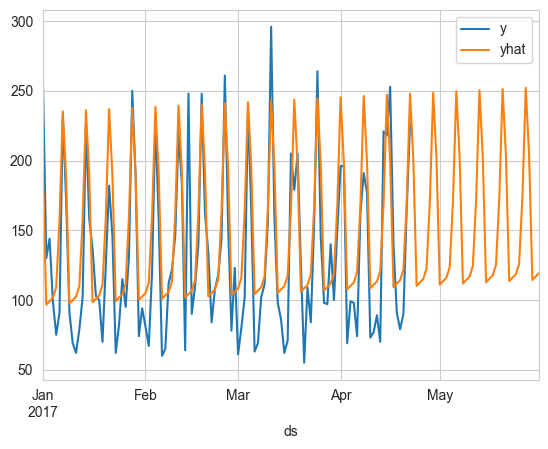

In [86]:
result.set_index('ds').plot()

In [87]:
perf_df = pd.DataFrame({"model": ["Univariate"], "RMSE": [rmse], "MAE": [mae]})
perf_df.head()

,model,RMSE,MAE
0,Univariate,34.689432,28.046783


### Multivariate Forecasting

#### Data preparation

In [88]:
# Preparing the data for multivariate time series analysis
# Convert 'weekday' and 'holiday_name' to categorical variables using get dummies
df = df.reset_index()
df['weekday'] = pd.Categorical(df['weekday'])
weekday_dummies = pd.get_dummies(df['weekday'], prefix='weekday')
holiday_name_dummies = pd.get_dummies(df['holiday_name'], prefix='holiday_name')

multi_data = pd.concat([df[['date', 'total', 'holiday']], weekday_dummies, holiday_name_dummies], axis=1)
multi_data = multi_data.rename(columns={'date': 'ds', 'total': 'y'})

multi_data.head()

,ds,y,holiday,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,...,holiday_name_Memorial Day,holiday_name_Mother's Day,holiday_name_New Year's Day,holiday_name_New Year's Eve,holiday_name_Presidents Day,holiday_name_St. Patrick's Day,holiday_name_Thanksgiving,holiday_name_Valentine's Day,holiday_name_Veterans' Day,holiday_name_na
0,2016-01-01,296.0,1,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2016-01-02,191.0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2016-01-03,202.0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2016-01-04,105.0,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2016-01-05,98.0,0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [89]:
# Splitting the data into training and validation sets
split_date = '2017-01-01'  # replace with the date where you want to split the data
train = multi_data[multi_data['ds'] < split_date]
test = multi_data[multi_data['ds'] >= split_date]

#### Model's Training


In [90]:

multi_data.columns

Index(['ds', 'y', 'holiday', 'weekday_Friday', 'weekday_Monday',
       'weekday_Saturday', 'weekday_Sunday', 'weekday_Thursday',
       'weekday_Tuesday', 'weekday_Wednesday', 'holiday_name_Black Friday',
       'holiday_name_Christmas Day', 'holiday_name_Christmas Eve',
       'holiday_name_Cinco de Mayo', 'holiday_name_Columbus Day',
       'holiday_name_Easter', 'holiday_name_Easter Monday',
       'holiday_name_Father's Day', 'holiday_name_Good Friday',
       'holiday_name_Groundhog Day', 'holiday_name_Halloween',
       'holiday_name_Independence Day', 'holiday_name_Labor Day',
       'holiday_name_Martin Luther King Day', 'holiday_name_Memorial Day',
       'holiday_name_Mother's Day', 'holiday_name_New Year's Day',
       'holiday_name_New Year's Eve', 'holiday_name_Presidents Day',
       'holiday_name_St. Patrick's Day', 'holiday_name_Thanksgiving',
       'holiday_name_Valentine's Day', 'holiday_name_Veterans' Day',
       'holiday_name_na'],
      dtype='object')

In [91]:
# Initializing the Prophet model for multivariate analysis
multi_model = Prophet()

# Adding the additional regressors
for column in multi_data.columns[2:]:
    print(column)
    multi_model.add_regressor(column)

holiday
weekday_Friday
weekday_Monday
weekday_Saturday
weekday_Sunday
weekday_Thursday
weekday_Tuesday
weekday_Wednesday
holiday_name_Black Friday
holiday_name_Christmas Day
holiday_name_Christmas Eve
holiday_name_Cinco de Mayo
holiday_name_Columbus Day
holiday_name_Easter
holiday_name_Easter Monday
holiday_name_Father's Day
holiday_name_Good Friday
holiday_name_Groundhog Day
holiday_name_Halloween
holiday_name_Independence Day
holiday_name_Labor Day
holiday_name_Martin Luther King Day
holiday_name_Memorial Day
holiday_name_Mother's Day
holiday_name_New Year's Day
holiday_name_New Year's Eve
holiday_name_Presidents Day
holiday_name_St. Patrick's Day
holiday_name_Thanksgiving
holiday_name_Valentine's Day
holiday_name_Veterans' Day
holiday_name_na


In [92]:
# Fit the model
multi_model.fit(train)

19:43:25 - cmdstanpy - INFO - Chain [1] start processing
19:43:25 - cmdstanpy - INFO - Chain [1] done processing


#### Forecasting

In [93]:
train.head()

,ds,y,holiday,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,...,holiday_name_Memorial Day,holiday_name_Mother's Day,holiday_name_New Year's Day,holiday_name_New Year's Eve,holiday_name_Presidents Day,holiday_name_St. Patrick's Day,holiday_name_Thanksgiving,holiday_name_Valentine's Day,holiday_name_Veterans' Day,holiday_name_na
0,2016-01-01,296.0,1,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2016-01-02,191.0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2016-01-03,202.0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2016-01-04,105.0,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2016-01-05,98.0,0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [94]:
test.head()

,ds,y,holiday,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,...,holiday_name_Memorial Day,holiday_name_Mother's Day,holiday_name_New Year's Day,holiday_name_New Year's Eve,holiday_name_Presidents Day,holiday_name_St. Patrick's Day,holiday_name_Thanksgiving,holiday_name_Valentine's Day,holiday_name_Veterans' Day,holiday_name_na
366,2017-01-01,256.0,1,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
367,2017-01-02,130.0,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
368,2017-01-03,144.0,0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
369,2017-01-04,99.0,0,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
370,2017-01-05,75.0,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [95]:
multi_data.head()

,ds,y,holiday,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,...,holiday_name_Memorial Day,holiday_name_Mother's Day,holiday_name_New Year's Day,holiday_name_New Year's Eve,holiday_name_Presidents Day,holiday_name_St. Patrick's Day,holiday_name_Thanksgiving,holiday_name_Valentine's Day,holiday_name_Veterans' Day,holiday_name_na
0,2016-01-01,296.0,1,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,2016-01-02,191.0,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,2016-01-03,202.0,0,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,2016-01-04,105.0,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2016-01-05,98.0,0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [96]:
# Making predictions on the validation set
future_multi = multi_model.make_future_dataframe(periods=len(test))

#add all the additional columns to future_multi
future_multi = pd.merge(future_multi, multi_data.drop("y", axis=1),how='left', on='ds')

forecast_multi = multi_model.predict(future_multi)

forecast_multi.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,...,weekday_Wednesday,weekday_Wednesday_lower,weekday_Wednesday_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-01-01,221.481240,263.365030,333.220088,221.481240,221.481240,76.102743,76.102743,76.102743,66.442824,...,0.0,0.0,0.0,9.659919,9.659919,9.659919,0.0,0.0,0.0,297.583983
1,2016-01-02,221.402258,199.170017,268.529536,221.402258,221.402258,13.757043,13.757043,13.757043,-60.963289,...,0.0,0.0,0.0,74.720332,74.720332,74.720332,0.0,0.0,0.0,235.159302
2,2016-01-03,221.323277,152.479173,218.719975,221.323277,221.323277,-36.773001,-36.773001,-36.773001,-72.192191,...,0.0,0.0,0.0,35.419190,35.419190,35.419190,0.0,0.0,0.0,184.550276
3,2016-01-04,221.244295,54.019028,121.932158,221.244295,221.244295,-133.505513,-133.505513,-133.505513,-93.688312,...,0.0,0.0,0.0,-39.817201,-39.817201,-39.817201,0.0,0.0,0.0,87.738782
4,2016-01-05,221.165313,67.947722,134.184555,221.165313,221.165313,-119.566013,-119.566013,-119.566013,-90.590627,...,0.0,0.0,0.0,-28.975386,-28.975386,-28.975386,0.0,0.0,0.0,101.599300


#### Analysis

In [99]:
y_pred_df_uni.shape, test.shape

((151, 2), (151, 34))

In [98]:
y_pred_df_multi = forecast_multi[forecast_multi['ds'] >= split_date][['ds', 'yhat']]

result = pd.merge(test[['ds', 'y']], y_pred_df_multi, how='inner')

result.head()


,ds,y,yhat
0,2017-01-01,256.0,326.724844
1,2017-01-02,130.0,84.100797
2,2017-01-03,144.0,98.143573
3,2017-01-04,99.0,100.526273
4,2017-01-05,75.0,104.998564


In [100]:
#calculate rmse
rmse = np.sqrt(np.mean((result['y']-result['yhat'])**2))
mae = (np.mean(np.abs(result['y']-result['yhat'])))

print(f"RMSE from Multivariate Analysis is : {rmse}")
print(f"MAE from Multivariate Analysis is : {mae}")

RMSE from Multivariate Analysis is : 29.83195108365765
MAE from Multivariate Analysis is : 23.64276725517515


In [101]:
perf_df = pd.concat([perf_df, pd.DataFrame({"model":["Multivariate"], "RMSE":[rmse], "MAE":[mae]})])
perf_df.head()

,model,RMSE,MAE
0,Univariate,34.689432,28.046783
0,Multivariate,29.831951,23.642767


<Axes: xlabel='ds'>

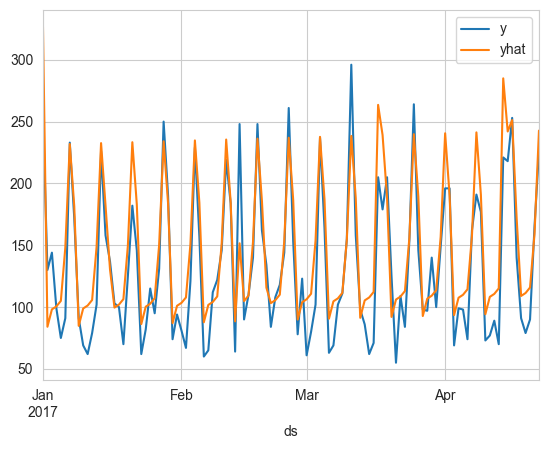

In [102]:
result.set_index('ds').dropna().plot()

#### Comparing Univariate vs Multivariate

<Axes: xlabel='model'>

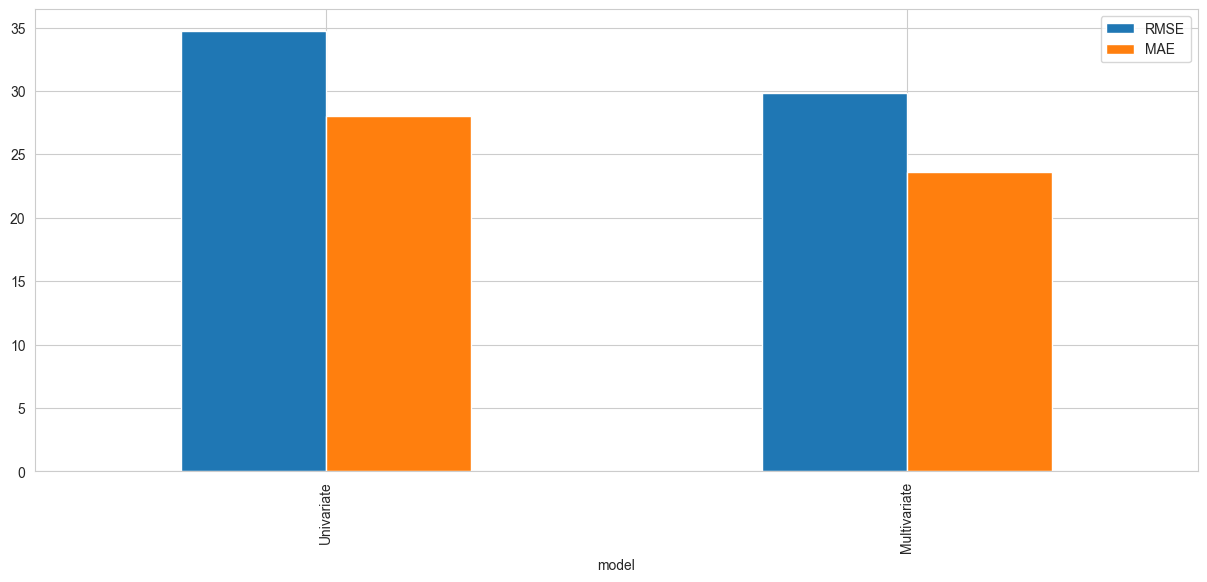

In [103]:
perf_df.set_index("model").plot(kind='bar', figsize=(15, 6))

In [104]:
y = test[['ds', 'y']].rename({"ds":"date", "y":"Actual"}, axis=1)
y_pred_df_multi = y_pred_df_multi.rename({"ds":"date", "yhat":"Multivariate Prediction"}, axis=1)
y_pred_df_uni = y_pred_df_uni.rename({"ds":"date", "yhat":"Univariate Prediction"}, axis=1)

plot_df = pd.merge(y_pred_df_multi, y, on=["date"], how="inner")
plot_df = pd.merge(plot_df, y_pred_df_uni, on=["date"], how="inner").set_index("date")

plot_df.head()

,Multivariate Prediction,Actual,Univariate Prediction
date,,,
2017-01-01,326.724844,256.0,187.109643
2017-01-02,84.100797,130.0,96.603769
2017-01-03,98.143573,144.0,99.124263
2017-01-04,100.526273,99.0,101.528272
2017-01-05,104.998564,75.0,109.045899


<Axes: xlabel='date'>

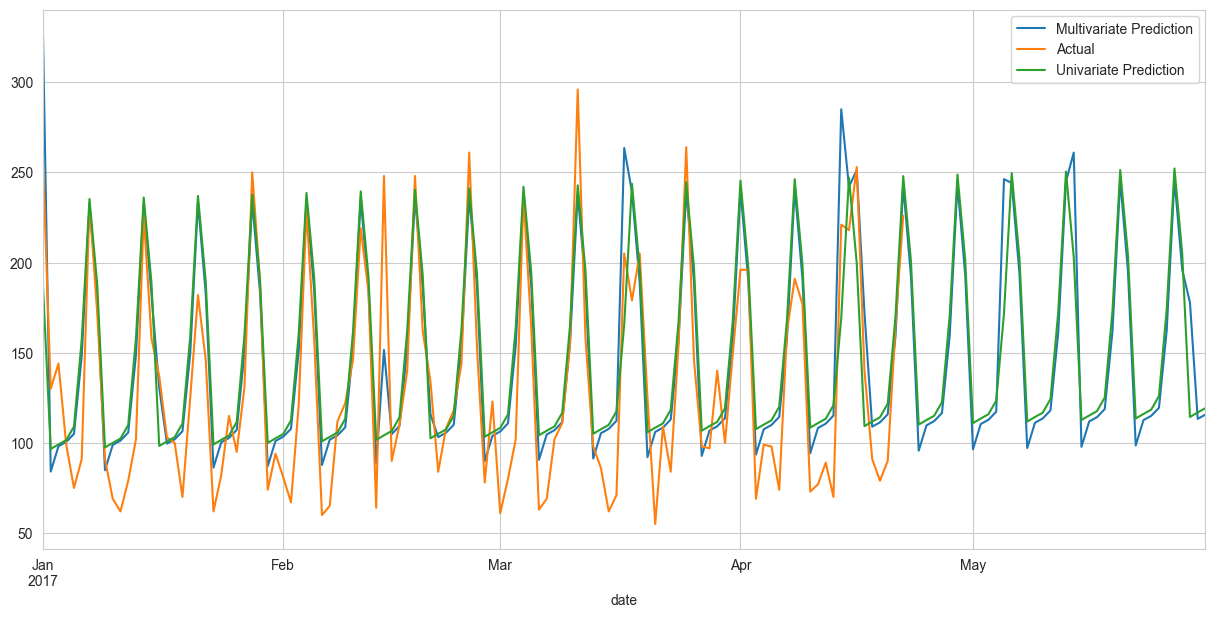

In [105]:
plot_df.plot(figsize=(15, 7))